# Sonderpädagogische Förderung in Deutschland (2000–2024)

## Analyseprojekt

**Thema:** Entwicklung, Struktur und mögliche Einflussfaktoren sonderpädagogischer Förderung in Deutschland  
**Datenquellen:** Destatis / GENESIS-Online  
**Analyseform:** deskriptive Datenanalyse mit Kontextualisierung und Hypothesenprüfung  

### Ziel der Analyse
Die Analyse untersucht, wie sich sonderpädagogische Förderung in Deutschland im Zeitraum 2000–2024 entwickelt hat. Im Fokus stehen die Gesamtentwicklung, strukturelle Unterschiede nach Schularten und Förderschwerpunkten sowie eine vorsichtige Einordnung möglicher externer Einflussfaktoren.

### Methodischer Hinweis
Die verwendeten Daten sind aggregierte Statistikdaten. Die Analyse kann Entwicklungen, Muster und zeitliche Zusammenhänge sichtbar machen. Sie kann jedoch keine Kausalität nachweisen.


# 0. Setup und Projektstruktur

## Ziel
In diesem Abschnitt werden Bibliotheken geladen, Projektpfade definiert und einheitliche Einstellungen für Tabellen und Diagramme gesetzt.

## Ergebnis
Alle späteren Analyseschritte nutzen dieselben Pfade, Formatierungen und Exportlogiken.


In [1]:
# ============================================================
# 0.1 Setup: Bibliotheken, Optionen und Pfade
# ============================================================

# Ziel:
# Einheitliche Arbeitsumgebung für Datenanalyse, Visualisierung und PNG-Export vorbereiten.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ------------------------------------------------------------
# Anzeigeoptionen für Tabellen
# ------------------------------------------------------------
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# ------------------------------------------------------------
# Projektpfade
# ------------------------------------------------------------
DATA_DIR = Path("../../data/processed")
OUTPUT_DIR = Path("../outputs")
CHART_DIR = OUTPUT_DIR / "charts"

FOERDER_PATH = DATA_DIR / "schueler_mit_foerderung_21111_0007_de_flat.csv"
SCHUELER_GESAMT_PATH = DATA_DIR / "schueler_gesamt_21111_0002_de_flat.csv"

CHART_DIR.mkdir(parents=True, exist_ok=True)

print("Setup abgeschlossen.")
print("Datenordner:", DATA_DIR)
print("Chart-Exportordner:", CHART_DIR)


Setup abgeschlossen.
Datenordner: ..\..\data\processed
Chart-Exportordner: ..\outputs\charts


In [2]:
# ============================================================
# 0.2 Hilfsfunktionen für konsistente Visualisierung
# ============================================================

# Ziel:
# Wiederkehrende Formatierungen zentral definieren, damit alle Diagramme gleich wirken.

def format_y_axis_thousands(ax):
    """Formatiert die Y-Achse mit deutschem Tausenderpunkt."""
    ax.get_yaxis().set_major_formatter(
        mticker.FuncFormatter(lambda x, pos: format(int(x), ",").replace(",", "."))
    )


def save_chart(fig, filename):
    """Speichert eine Matplotlib-Figure als PNG im Chart-Ordner."""
    filepath = CHART_DIR / filename
    fig.savefig(filepath, dpi=300, bbox_inches="tight")
    print(f"PNG gespeichert: {filepath}")


def standard_grid(ax, axis="y"):
    """Setzt ein dezentes Grid für bessere Lesbarkeit."""
    ax.grid(axis=axis, alpha=0.3)


In [3]:
# ============================================================
# 0.3 Eingabedateien prüfen
# ============================================================

# Ziel:
# Vor dem Einlesen prüfen, ob die benötigten CSV-Dateien vorhanden sind.

for path in [FOERDER_PATH, SCHUELER_GESAMT_PATH]:
    print(path, "->", "vorhanden" if path.exists() else "FEHLT")


..\..\data\processed\schueler_mit_foerderung_21111_0007_de_flat.csv -> vorhanden
..\..\data\processed\schueler_gesamt_21111_0002_de_flat.csv -> vorhanden


# 1. Datengrundlage und methodische Entscheidungen

## Ziel
Der Kerndatensatz zur sonderpädagogischen Förderung wird eingelesen, fachlich beschrieben und in einen analysefähigen DataFrame überführt.

## Zentrale Entscheidungen
- Technische GENESIS-Spalten werden auf fachliche Analysevariablen reduziert.
- Aggregierte `Insgesamt`-Zeilen werden für Detailanalysen entfernt.
- Fehlende oder nicht ausgewiesene Werte werden nicht automatisch als 0 interpretiert.


## 1.1 Fachliche Vorstellung des Kerndatensatzes

| Variable im Analyse-Datensatz | Bedeutung | Verwendung |
|---|---|---|
| `jahr` | Schuljahr als Kalenderjahr | Zeitdimension |
| `schulart` | Schulart / Schulform | Strukturvergleich nach Schulart |
| `foerderschwerpunkt` | Art der sonderpädagogischen Förderung | Analyse der Förderbereiche |
| `anzahl_schueler` | Anzahl der Schülerinnen und Schüler | zentrale Kennzahl |

### Genutzte Rohspalten
| Rohspalte | Zielspalte | Entscheidung |
|---|---|---|
| `time` | `jahr` | Jahr aus Schuljahr extrahiert |
| `2_variable_attribute_label` | `schulart` | behalten |
| `3_variable_attribute_label` | `foerderschwerpunkt` | behalten |
| `value` | `anzahl_schueler` | numerisch bereinigt |

### Entfernte Inhalte
- technische Codes und redundante Beschreibungen
- `Insgesamt`-Kategorien für Detailanalysen
- fehlende/nicht ausgewiesene Werte in der Kennzahl


In [4]:
# ============================================================
# 1.2 CSV einlesen: Förderdatensatz
# ============================================================

# Ziel:
# Rohdaten unverändert einlesen und danach mit einer Arbeitskopie weiterarbeiten.

df_raw = pd.read_csv(FOERDER_PATH, sep=";")
df_clean = df_raw.copy()

print("Förderdatensatz eingelesen.")
print("Shape Rohdaten:", df_raw.shape)
df_raw.head()


Förderdatensatz eingelesen.
Shape Rohdaten: (3000, 21)


,statistics_code,statistics_label,time_code,time_label,time,1_variable_code,1_variable_label,1_variable_attribute_code,1_variable_attribute_label,2_variable_code,2_variable_label,2_variable_attribute_code,2_variable_attribute_label,3_variable_code,3_variable_label,3_variable_attribute_code,3_variable_attribute_label,value,value_unit,value_variable_code,value_variable_label
0,21111,Statistik der allgemeinbildenden Schulen,SLJAHR,Schuljahr,2000-P1Y,DINSG,Deutschland insgesamt,DG,Deutschland,BILSA2,Schulart,SCHULE05,Hauptschulen,BILFO1,Förderschwerpunkte,FOERD-SPR,Sprache,401,Anzahl,BIL012,Schüler mit sonderpädagogischer Förderung
1,21111,Statistik der allgemeinbildenden Schulen,SLJAHR,Schuljahr,2000-P1Y,DINSG,Deutschland insgesamt,DG,Deutschland,BILSA2,Schulart,SCHULE09,Schularten mit drei Bildungsgängen,BILFO1,Förderschwerpunkte,NaN,Insgesamt,3856,Anzahl,BIL012,Schüler mit sonderpädagogischer Förderung
2,21111,Statistik der allgemeinbildenden Schulen,SLJAHR,Schuljahr,2003-P1Y,DINSG,Deutschland insgesamt,DG,Deutschland,BILSA2,Schulart,SCHULE11,Förderschulen,BILFO1,Förderschwerpunkte,FOERD-SEH,Sehen,4736,Anzahl,BIL012,Schüler mit sonderpädagogischer Förderung
3,21111,Statistik der allgemeinbildenden Schulen,SLJAHR,Schuljahr,2021-P1Y,DINSG,Deutschland insgesamt,DG,Deutschland,BILSA2,Schulart,SCHULE09,Schularten mit drei Bildungsgängen,BILFO1,Förderschwerpunkte,FOERD-X,Keinem Schwerpunkt zugeordnet,1087,Anzahl,BIL012,Schüler mit sonderpädagogischer Förderung
4,21111,Statistik der allgemeinbildenden Schulen,SLJAHR,Schuljahr,2008-P1Y,DINSG,Deutschland insgesamt,DG,Deutschland,BILSA2,Schulart,SCHULE12-15,Abendschulen und Kollegs,BILFO1,Förderschwerpunkte,FOERD-SEH,Sehen,-,Anzahl,BIL012,Schüler mit sonderpädagogischer Förderung


In [5]:
# ============================================================
# 1.3 Erster technischer Überblick
# ============================================================

# Ziel:
# Spalten, Datentypen und erste Zeilen prüfen, bevor Transformationen vorgenommen werden.

print("Spalten:")
print(df_clean.columns.tolist())

print("\nDatentypen:")
print(df_clean.dtypes)

print("\nErste Zeilen:")
display(df_clean.head())

print("\nShape:")
print(df_clean.shape)

Spalten:
['statistics_code', 'statistics_label', 'time_code', 'time_label', 'time', '1_variable_code', '1_variable_label', '1_variable_attribute_code', '1_variable_attribute_label', '2_variable_code', '2_variable_label', '2_variable_attribute_code', '2_variable_attribute_label', '3_variable_code', '3_variable_label', '3_variable_attribute_code', '3_variable_attribute_label', 'value', 'value_unit', 'value_variable_code', 'value_variable_label']

Datentypen:
statistics_code               int64
statistics_label                str
time_code                       str
time_label                      str
time                            str
1_variable_code                 str
1_variable_label                str
1_variable_attribute_code       str
1_variable_attribute_label      str
2_variable_code                 str
2_variable_label                str
2_variable_attribute_code       str
2_variable_attribute_label      str
3_variable_code                 str
3_variable_label                str

,statistics_code,statistics_label,time_code,time_label,time,1_variable_code,1_variable_label,1_variable_attribute_code,1_variable_attribute_label,2_variable_code,2_variable_label,2_variable_attribute_code,2_variable_attribute_label,3_variable_code,3_variable_label,3_variable_attribute_code,3_variable_attribute_label,value,value_unit,value_variable_code,value_variable_label
0,21111,Statistik der allgemeinbildenden Schulen,SLJAHR,Schuljahr,2000-P1Y,DINSG,Deutschland insgesamt,DG,Deutschland,BILSA2,Schulart,SCHULE05,Hauptschulen,BILFO1,Förderschwerpunkte,FOERD-SPR,Sprache,401,Anzahl,BIL012,Schüler mit sonderpädagogischer Förderung
1,21111,Statistik der allgemeinbildenden Schulen,SLJAHR,Schuljahr,2000-P1Y,DINSG,Deutschland insgesamt,DG,Deutschland,BILSA2,Schulart,SCHULE09,Schularten mit drei Bildungsgängen,BILFO1,Förderschwerpunkte,NaN,Insgesamt,3856,Anzahl,BIL012,Schüler mit sonderpädagogischer Förderung
2,21111,Statistik der allgemeinbildenden Schulen,SLJAHR,Schuljahr,2003-P1Y,DINSG,Deutschland insgesamt,DG,Deutschland,BILSA2,Schulart,SCHULE11,Förderschulen,BILFO1,Förderschwerpunkte,FOERD-SEH,Sehen,4736,Anzahl,BIL012,Schüler mit sonderpädagogischer Förderung
3,21111,Statistik der allgemeinbildenden Schulen,SLJAHR,Schuljahr,2021-P1Y,DINSG,Deutschland insgesamt,DG,Deutschland,BILSA2,Schulart,SCHULE09,Schularten mit drei Bildungsgängen,BILFO1,Förderschwerpunkte,FOERD-X,Keinem Schwerpunkt zugeordnet,1087,Anzahl,BIL012,Schüler mit sonderpädagogischer Förderung
4,21111,Statistik der allgemeinbildenden Schulen,SLJAHR,Schuljahr,2008-P1Y,DINSG,Deutschland insgesamt,DG,Deutschland,BILSA2,Schulart,SCHULE12-15,Abendschulen und Kollegs,BILFO1,Förderschwerpunkte,FOERD-SEH,Sehen,-,Anzahl,BIL012,Schüler mit sonderpädagogischer Förderung



Shape:
(3000, 21)


In [6]:
# ============================================================
# 1.4 Spalten fachlich umbenennen
# ============================================================

# Ziel:
# Technische GENESIS-Spaltennamen in verständliche Analyse-Spalten umbenennen.

df_clean = df_clean.rename(columns={
    "time": "schuljahr",
    "2_variable_attribute_code": "schulart_code",
    "2_variable_attribute_label": "schulart",
    "3_variable_attribute_code": "foerderschwerpunkt_code",
    "3_variable_attribute_label": "foerderschwerpunkt",
    "value": "anzahl_schueler"
})

# Kontrolle: relevante Spalten anzeigen
relevante_spalten = [
    "schuljahr",
    "schulart_code",
    "schulart",
    "foerderschwerpunkt_code",
    "foerderschwerpunkt",
    "anzahl_schueler"
]

df_clean[relevante_spalten].head()


,schuljahr,schulart_code,schulart,foerderschwerpunkt_code,foerderschwerpunkt,anzahl_schueler
0,2000-P1Y,SCHULE05,Hauptschulen,FOERD-SPR,Sprache,401
1,2000-P1Y,SCHULE09,Schularten mit drei Bildungsgängen,NaN,Insgesamt,3856
2,2003-P1Y,SCHULE11,Förderschulen,FOERD-SEH,Sehen,4736
3,2021-P1Y,SCHULE09,Schularten mit drei Bildungsgängen,FOERD-X,Keinem Schwerpunkt zugeordnet,1087
4,2008-P1Y,SCHULE12-15,Abendschulen und Kollegs,FOERD-SEH,Sehen,-


In [7]:
# ============================================================
# 1.5 Datentypen bereinigen
# ============================================================

# Ziel:
# - Schülerzahlen numerisch nutzbar machen.
# - Jahr aus dem Schuljahr ableiten.
# - Textdimensionen als Kategorien speichern.

# Hinweis:
# In GENESIS-Exporten kann "-" bedeuten:
# - kein Wert vorhanden,
# - Wert exakt 0,
# - Wert aus Datenschutz-/Geheimhaltungsgründen unterdrückt.
# Deshalb werden diese Werte als NaN behandelt und nicht automatisch als 0 interpretiert.

df_clean["anzahl_schueler"] = (
    df_clean["anzahl_schueler"]
    .astype(str)
    .str.strip()
    .replace("-", np.nan)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
)

df_clean["anzahl_schueler"] = pd.to_numeric(
    df_clean["anzahl_schueler"],
    errors="coerce"
)

# Jahr aus Schuljahr extrahieren: z. B. "2000-P1Y" -> 2000
df_clean["jahr"] = df_clean["schuljahr"].astype(str).str[:4].astype(int)

# Kategorien setzen
for col in ["schulart", "foerderschwerpunkt"]:
    df_clean[col] = df_clean[col].astype("category")

# Kontrolle
df_clean[["schuljahr", "jahr", "schulart", "foerderschwerpunkt", "anzahl_schueler"]].head()


,schuljahr,jahr,schulart,foerderschwerpunkt,anzahl_schueler
0,2000-P1Y,2000,Hauptschulen,Sprache,401.00
1,2000-P1Y,2000,Schularten mit drei Bildungsgängen,Insgesamt,"3,856.00"
2,2003-P1Y,2003,Förderschulen,Sehen,"4,736.00"
3,2021-P1Y,2021,Schularten mit drei Bildungsgängen,Keinem Schwerpunkt zugeordnet,"1,087.00"
4,2008-P1Y,2008,Abendschulen und Kollegs,Sehen,NaN


In [8]:
# ============================================================
# 1.6 Qualitätscheck nach Typumwandlung
# ============================================================

# Ziel:
# Prüfen, wie viele Werte nach der Umwandlung fehlen und welche Jahre abgedeckt sind.

print("Zeitraum:", df_clean["jahr"].min(), "-", df_clean["jahr"].max())
print("Fehlende Werte in anzahl_schueler:", df_clean["anzahl_schueler"].isna().sum())

print("Anzahl Schularten:", df_clean["schulart"].nunique())
print("Anzahl Förderschwerpunkte:", df_clean["foerderschwerpunkt"].nunique())


Zeitraum: 2000 - 2024
Fehlende Werte in anzahl_schueler: 439
Anzahl Schularten: 12
Anzahl Förderschwerpunkte: 10


## 1.7 Entscheidung: Umgang mit `Insgesamt`-Zeilen

Die Kategorie `Insgesamt` ist kein zusätzlicher Detailwert, sondern bereits ein aggregierter Summenwert über mehrere Ausprägungen.

Wenn `Insgesamt` gemeinsam mit Detailwerten analysiert würde, entstehen:
- Doppelzählungen,
- überhöhte Summen,
- verzerrte Anteile,
- fachlich falsche Interpretationen.

### Entscheidung
Für Detailanalysen werden `Insgesamt`-Werte in `schulart` und `foerderschwerpunkt` entfernt.


In [9]:
# ============================================================
# 1.8 Detail-Datensatz erstellen
# ============================================================

# Ziel:
# Nur echte Detailkombinationen aus Schulart und Förderschwerpunkt behalten.

# Schritt 1: Aggregierte "Insgesamt"-Kategorien entfernen
df_detail = df_clean[
    (df_clean["schulart"].astype(str) != "Insgesamt") &
    (df_clean["foerderschwerpunkt"].astype(str) != "Insgesamt")
].copy()

# Schritt 2: Fehlende Schülerzahlen entfernen
# Begründung: NaN kann in diesem Datensatz statistische Maskierung bedeuten und wird nicht als 0 umgedeutet.
df_analysis = df_detail.dropna(subset=["anzahl_schueler"]).copy()

# Schritt 3: Relevante Analyse-Spalten behalten
df_analysis = df_analysis[[
    "jahr",
    "schulart",
    "foerderschwerpunkt",
    "anzahl_schueler"
]].copy()

# Schritt 4: Datentypen finalisieren
df_analysis["jahr"] = df_analysis["jahr"].astype(int)
df_analysis["anzahl_schueler"] = df_analysis["anzahl_schueler"].astype(float)
df_analysis["schulart"] = df_analysis["schulart"].astype("category").cat.remove_unused_categories()
df_analysis["foerderschwerpunkt"] = df_analysis["foerderschwerpunkt"].astype("category").cat.remove_unused_categories()

# Kontrolle
print("Analyse-Datensatz Förderbedarf:", df_analysis.shape)
df_analysis.head()


Analyse-Datensatz Förderbedarf: (2069, 4)


,jahr,schulart,foerderschwerpunkt,anzahl_schueler
0,2000,Hauptschulen,Sprache,401.00
2,2003,Förderschulen,Sehen,"4,736.00"
3,2021,Schularten mit drei Bildungsgängen,Keinem Schwerpunkt zugeordnet,"1,087.00"
5,2015,Schulartunabhängige Orientierungsstufen,Sprache,692.00
6,2018,Schularten mit zwei Bildungsgängen,Keinem Schwerpunkt zugeordnet,66.00


In [10]:
# ============================================================
# 1.9 Kontrollcheck: Entfernte Kategorien und Missing Values
# ============================================================

# Ziel:
# Sicherstellen, dass im Analyse-Datensatz keine "Insgesamt"-Zeilen mehr enthalten sind.

check_insgesamt_schulart = (df_analysis["schulart"].astype(str) == "Insgesamt").sum()
check_insgesamt_schwerpunkt = (df_analysis["foerderschwerpunkt"].astype(str) == "Insgesamt").sum()
check_missing = df_analysis["anzahl_schueler"].isna().sum()

print("Schulart = Insgesamt:", check_insgesamt_schulart)
print("Förderschwerpunkt = Insgesamt:", check_insgesamt_schwerpunkt)
print("Fehlende Werte in anzahl_schueler:", check_missing)


Schulart = Insgesamt: 0
Förderschwerpunkt = Insgesamt: 0
Fehlende Werte in anzahl_schueler: 0


# 2. Fragestellung 1: Wie entwickelt sich die Gesamtzahl der Förderung?

## Ziel
Die erste Fragestellung ist deskriptiv. Sie zeigt, ob sich die absolute Anzahl der Schülerinnen und Schüler mit sonderpädagogischer Förderung über die Zeit verändert.

## Erwartung an die Analyse
- langfristigen Trend sichtbar machen,
- auffällige Zeitpunkte erkennen,
- noch keine Ursachen ableiten.


In [11]:
# ============================================================
# 2.1 Gesamtentwicklung berechnen
# ============================================================

# Ziel:
# Gesamtzahl aller Schülerinnen und Schüler mit sonderpädagogischer Förderung je Jahr berechnen.

df_gesamtentwicklung = (
    df_analysis
    .groupby("jahr", as_index=False, observed=True)["anzahl_schueler"]
    .sum()
    .rename(columns={"anzahl_schueler": "anzahl_schueler_foerder"})
)

df_gesamtentwicklung.head()


,jahr,anzahl_schueler_foerder
0,2000,"466,921.00"
1,2001,"474,998.00"
2,2002,"483,105.00"
3,2003,"478,409.00"
4,2004,"476,958.00"


PNG gespeichert: ..\outputs\charts\01_gesamtentwicklung_dual.png


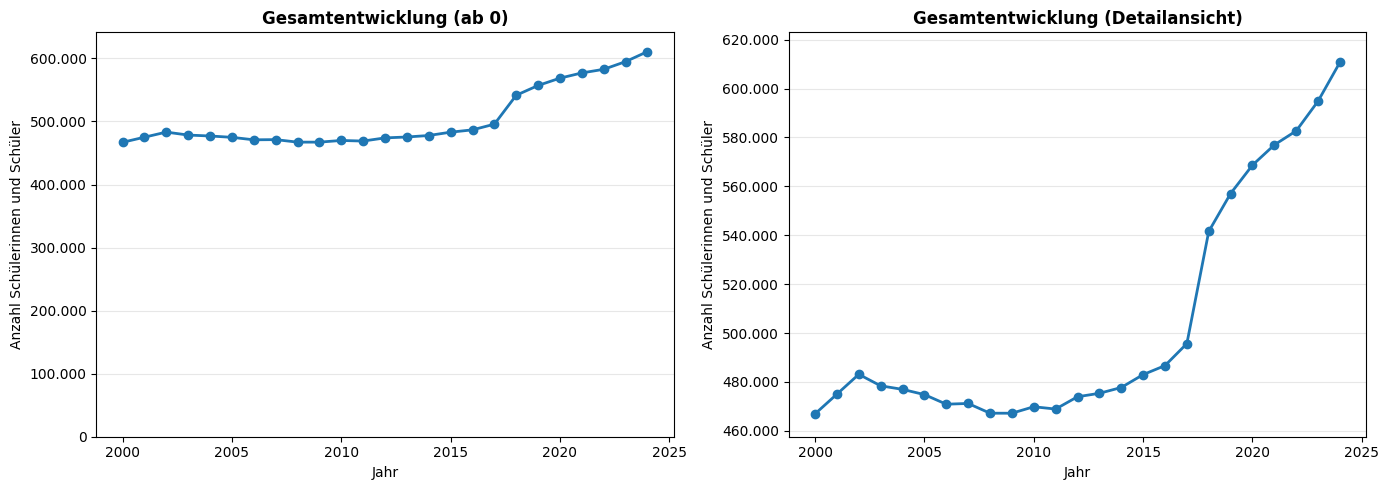

In [12]:
# ============================================================
# 2.2 Visual V01: Gesamtentwicklung - Überblick und Detailansicht
# ============================================================

# Ziel:
# Zwei Perspektiven zeigen:
# - links: y-Achse startet bei 0, um Größenordnung nicht zu überzeichnen.
# - rechts: Detailansicht, um Dynamik besser sichtbar zu machen.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------------------------
# Chart 1: neutrale Darstellung ab 0
# ------------------------------------------------------------
ax1.plot(
    df_gesamtentwicklung["jahr"],
    df_gesamtentwicklung["anzahl_schueler_foerder"],
    marker="o",
    linewidth=2
)
ax1.set_title("Gesamtentwicklung (ab 0)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Jahr")
ax1.set_ylabel("Anzahl Schülerinnen und Schüler")
ax1.set_ylim(0, df_gesamtentwicklung["anzahl_schueler_foerder"].max() * 1.05)
standard_grid(ax1)
format_y_axis_thousands(ax1)

# ------------------------------------------------------------
# Chart 2: Detailansicht
# ------------------------------------------------------------
ax2.plot(
    df_gesamtentwicklung["jahr"],
    df_gesamtentwicklung["anzahl_schueler_foerder"],
    marker="o",
    linewidth=2
)
ax2.set_title("Gesamtentwicklung (Detailansicht)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Jahr")
ax2.set_ylabel("Anzahl Schülerinnen und Schüler")
ax2.set_ylim(
    df_gesamtentwicklung["anzahl_schueler_foerder"].min() * 0.98,
    df_gesamtentwicklung["anzahl_schueler_foerder"].max() * 1.02
)
standard_grid(ax2)
format_y_axis_thousands(ax2)

plt.tight_layout()
save_chart(fig, "01_gesamtentwicklung_dual.png")
plt.show()


## Antwort auf Fragestellung 1

Die Gesamtzahl der Schülerinnen und Schüler mit sonderpädagogischer Förderung steigt langfristig deutlich an. Bis etwa 2010 ist zunächst ein leichter Rückgang bzw. eine Seitwärtsbewegung erkennbar. Danach folgt ein kontinuierlicher Anstieg, der ab 2017/2018 deutlich stärker ausfällt.

### Einschränkung
Die Visualisierung zeigt eine zeitliche Entwicklung, aber keine Ursache für den Anstieg.


# 3. Fragestellung 2: Welche Schularten und Förderschwerpunkte prägen die Struktur?

## Ziel
Dieser Abschnitt untersucht die strukturelle Verteilung der Förderung:
- nach Schularten,
- nach Förderschwerpunkten,
- nach zeitlicher Entwicklung der wichtigsten Kategorien.


In [13]:
# ============================================================
# 3.1 Schularten: Gesamtvolumen und Zeitverlauf berechnen
# ============================================================

# Ziel:
# Struktur nach Schularten vorbereiten.

df_schulart_summe = (
    df_analysis
    .groupby("schulart", as_index=False, observed=True)["anzahl_schueler"]
    .sum()
    .sort_values("anzahl_schueler", ascending=False)
)

df_schulart_jahr = (
    df_analysis
    .groupby(["jahr", "schulart"], as_index=False, observed=True)["anzahl_schueler"]
    .sum()
)

top_schularten = df_schulart_summe.head(6)["schulart"].astype(str).tolist()

df_schulart_summe.head(10)


,schulart,anzahl_schueler
1,Förderschulen,"8,949,988.00"
2,Grundschulen,"1,679,742.00"
7,Schularten mit drei Bildungsgängen,"755,388.00"
5,Hauptschulen,"426,682.00"
8,Schularten mit zwei Bildungsgängen,"382,364.00"
6,Realschulen,"144,041.00"
9,Schulartunabhängige Orientierungsstufen,"126,863.00"
3,Gymnasien (G8),"76,671.00"
4,Gymnasien (G9),"42,300.00"
0,Freie Waldorfschulen,"11,423.00"


PNG gespeichert: ..\outputs\charts\02_schularten_verteilung_entwicklung.png


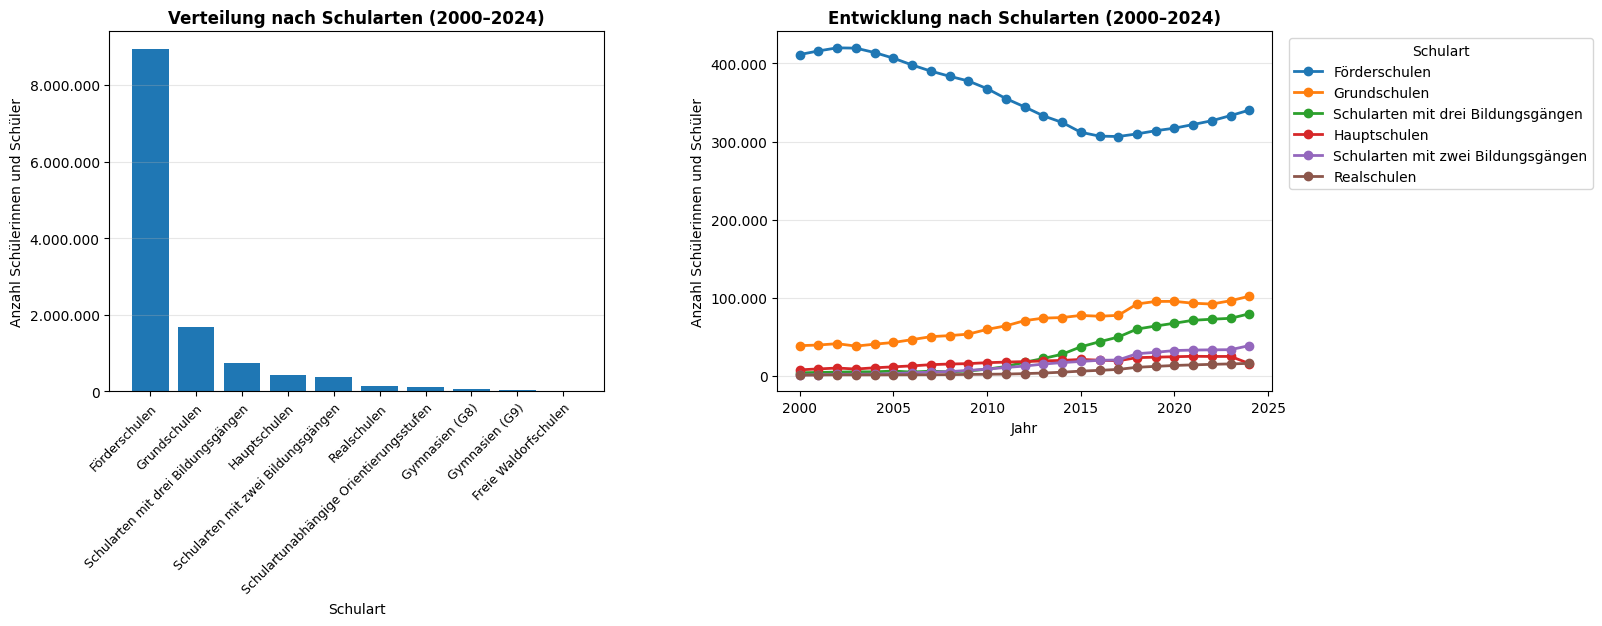

In [14]:
# ============================================================
# 3.2 Visual V2: Schularten – Verteilung und Entwicklung
# ============================================================

# Ziel:
# Links: Gesamtvolumen nach Schulart.
# Rechts: Entwicklung der wichtigsten Schularten über die Zeit.


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ------------------------------------------------------------
# Links: Verteilung
# ------------------------------------------------------------

x_labels = df_schulart_summe["schulart"].astype(str)

ax1.bar(
    x_labels,
    df_schulart_summe["anzahl_schueler"]
)

ax1.set_title(
    "Verteilung nach Schularten (2000–2024)",
    fontsize=12,
    fontweight="bold"
)

ax1.set_xlabel("Schulart")
ax1.set_ylabel("Anzahl Schülerinnen und Schüler")

# Wichtig:
# Rotation + ha="right" sorgt dafür, dass die Labels korrekt unter den Balken stehen.
ax1.tick_params(axis="x", rotation=45, labelsize=9)

for label in ax1.get_xticklabels():
    label.set_horizontalalignment("right")
    label.set_rotation_mode("anchor")

standard_grid(ax1)
format_y_axis_thousands(ax1)

# ------------------------------------------------------------
# Rechts: Zeitverlauf Top-Schularten
# ------------------------------------------------------------

df_top_schularten = df_schulart_jahr[
    df_schulart_jahr["schulart"].astype(str).isin(top_schularten)
].copy()

for schulart in top_schularten:
    daten = df_top_schularten[
        df_top_schularten["schulart"].astype(str) == schulart
    ]

    ax2.plot(
        daten["jahr"],
        daten["anzahl_schueler"],
        marker="o",
        linewidth=2,
        label=schulart
    )

ax2.set_title(
    "Entwicklung nach Schularten (2000–2024)",
    fontsize=12,
    fontweight="bold"
)

ax2.set_xlabel("Jahr")
ax2.set_ylabel("Anzahl Schülerinnen und Schüler")

standard_grid(ax2)
format_y_axis_thousands(ax2)

ax2.legend(
    title="Schulart",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# Mehr Platz unten für schräge Achsenbeschriftungen
plt.subplots_adjust(bottom=0.28, wspace=0.35)

save_chart(fig, "02_schularten_verteilung_entwicklung.png")
plt.show()

## Interpretation: Schularten

Die Förderung konzentriert sich stark auf Förderschulen. Gleichzeitig ist in allgemeinen Schularten, insbesondere Grundschulen und Schularten mit mehreren Bildungsgängen, ein deutlicher Anstieg sichtbar.

### Hinweis
Die Darstellung basiert auf absoluten Fallzahlen. Sie berücksichtigt noch nicht die Gesamtgröße der jeweiligen Schulart.


In [15]:
# ============================================================
# 3.3 Förderschwerpunkte: Gesamtvolumen berechnen
# ============================================================

# Ziel:
# Ermitteln, welche Förderschwerpunkte über den gesamten Zeitraum dominieren.

df_schwerpunkt_summe = (
    df_analysis
    .groupby("foerderschwerpunkt", as_index=False, observed=True)["anzahl_schueler"]
    .sum()
    .sort_values("anzahl_schueler", ascending=False)
)

df_schwerpunkt_summe.head(10)


,foerderschwerpunkt,anzahl_schueler
6,Lernen,"5,421,714.00"
2,Geistige Entwicklung,"2,114,136.00"
0,Emotionale und soziale Entwicklung,"1,776,475.00"
8,Sprache,"1,311,021.00"
5,Körperliche und motorische Entwicklung,"822,843.00"
3,Hören,"410,671.00"
1,Förderschwerpunktübergreifend,"299,875.00"
4,Keinem Schwerpunkt zugeordnet,"255,842.00"
7,Sehen,"182,885.00"


PNG gespeichert: ..\outputs\charts\03_foerderschwerpunkte_verteilung.png


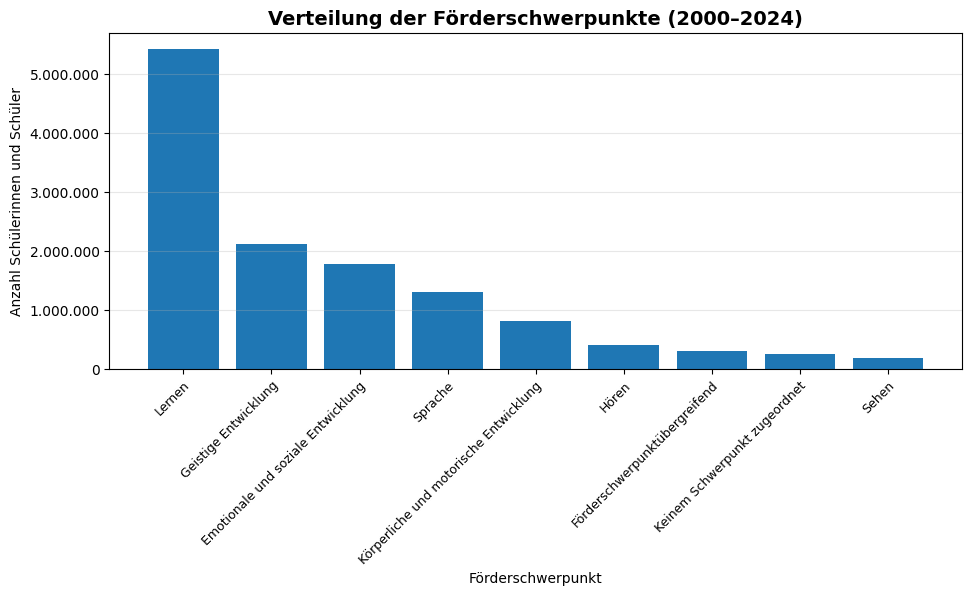

In [16]:
# ============================================================
# 3.4 Visual V3: Verteilung nach Förderschwerpunkten
# ============================================================

# Ziel:
# Dominierende Förderschwerpunkte im Gesamtsystem sichtbar machen.


df_plot = df_schwerpunkt_summe.copy()

fig, ax = plt.subplots(figsize=(11, 6))

# ------------------------------------------------------------
# Balkendiagramm
# ------------------------------------------------------------

x_labels = df_plot["foerderschwerpunkt"].astype(str)

ax.bar(
    x_labels,
    df_plot["anzahl_schueler"]
)

# ------------------------------------------------------------
# Titel und Achsen
# ------------------------------------------------------------

ax.set_title(
    "Verteilung der Förderschwerpunkte (2000–2024)",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Förderschwerpunkt")
ax.set_ylabel("Anzahl Schülerinnen und Schüler")

# ------------------------------------------------------------
# X-Achsen-Beschriftungen sauber ausrichten
# ------------------------------------------------------------

ax.tick_params(axis="x", rotation=45, labelsize=9)

for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
    label.set_rotation_mode("anchor")

# ------------------------------------------------------------
# Standardformatierung
# ------------------------------------------------------------

standard_grid(ax)
format_y_axis_thousands(ax)

# Mehr Platz unten für lange Beschriftungen
plt.subplots_adjust(bottom=0.32)

# ------------------------------------------------------------
# Export
# ------------------------------------------------------------

save_chart(fig, "03_foerderschwerpunkte_verteilung.png")
plt.show()

In [17]:
# ============================================================
# 3.5 Förderschwerpunkte: Zeitverlauf und Strukturanteile berechnen
# ============================================================

# Ziel:
# Entwicklung und relative Bedeutung der wichtigsten Förderschwerpunkte analysieren.

df_schwerpunkt_jahr = (
    df_analysis
    .groupby(["jahr", "foerderschwerpunkt"], as_index=False, observed=True)["anzahl_schueler"]
    .sum()
)

top_schwerpunkte = (
    df_schwerpunkt_summe
    .head(5)["foerderschwerpunkt"]
    .astype(str)
    .tolist()
)

# Anteil pro Jahr berechnen
df_schwerpunkt_anteil = df_schwerpunkt_jahr.copy()
df_schwerpunkt_anteil["gesamt_jahr"] = (
    df_schwerpunkt_anteil
    .groupby("jahr", observed=True)["anzahl_schueler"]
    .transform("sum")
)
df_schwerpunkt_anteil["anteil_prozent"] = (
    df_schwerpunkt_anteil["anzahl_schueler"] /
    df_schwerpunkt_anteil["gesamt_jahr"] * 100
).round(2)

print("Top 5 Förderschwerpunkte:")
print(top_schwerpunkte)


Top 5 Förderschwerpunkte:
['Lernen', 'Geistige Entwicklung', 'Emotionale und soziale Entwicklung', 'Sprache', 'Körperliche und motorische Entwicklung']


PNG gespeichert: ..\outputs\charts\04_top5_dynamik_anteil.png


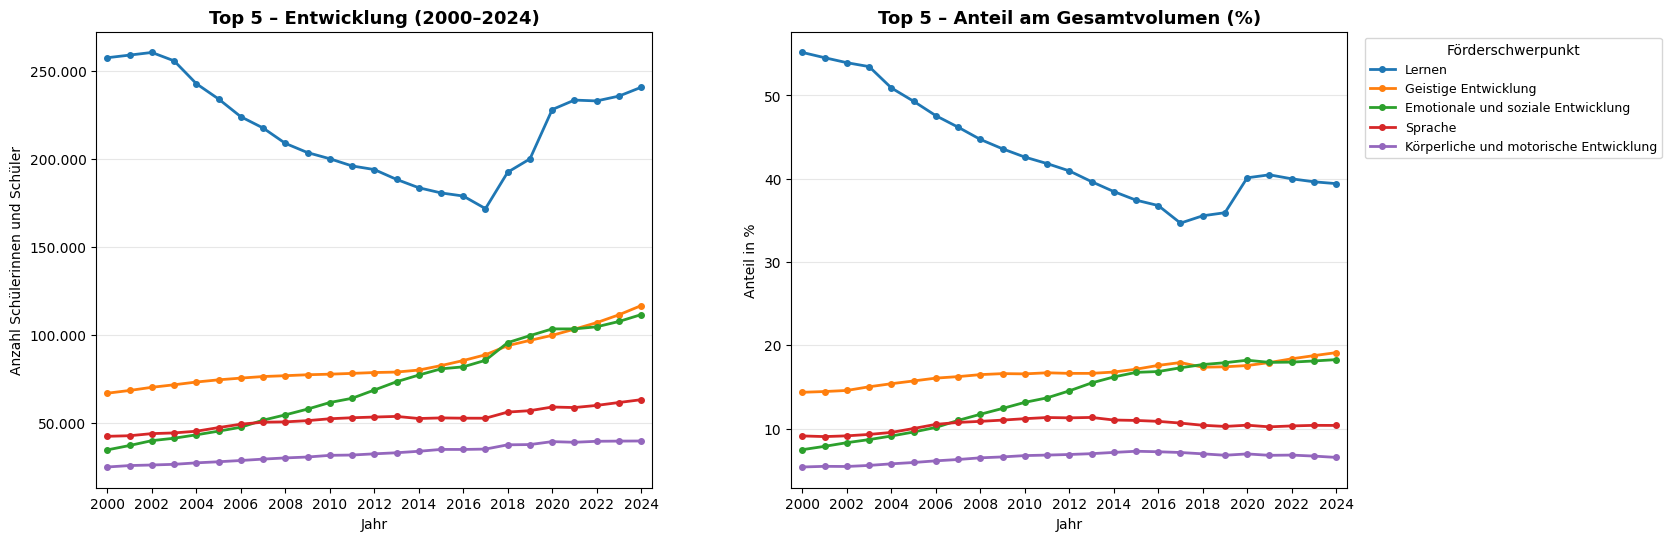

In [18]:
# ============================================================
# 3.6 Visual V04: Top 5 Förderschwerpunkte – Entwicklung und Anteil
# ============================================================

# Ziel:
# Links: absolute Entwicklung.
# Rechts: strukturelle Bedeutung als Anteil am Gesamtvolumen.
# Anpassung:
# X-Achse wird breiter verteilt, ohne den Abstand zwischen den beiden Visuals stark zu verändern.

df_top_schwerpunkte = df_schwerpunkt_jahr[
    df_schwerpunkt_jahr["foerderschwerpunkt"].astype(str).isin(top_schwerpunkte)
].copy()

df_top_anteil = df_schwerpunkt_anteil[
    df_schwerpunkt_anteil["foerderschwerpunkt"].astype(str).isin(top_schwerpunkte)
].copy()

# Breitere Figure: mehr Platz auf der X-Achse
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# ------------------------------------------------------------
# Links: absolute Entwicklung
# ------------------------------------------------------------

for schwerpunkt in top_schwerpunkte:
    daten = df_top_schwerpunkte[
        df_top_schwerpunkte["foerderschwerpunkt"].astype(str) == schwerpunkt
    ]

    ax1.plot(
        daten["jahr"],
        daten["anzahl_schueler"],
        marker="o",
        linewidth=2,
        markersize=4,
        label=schwerpunkt
    )

ax1.set_title(
    "Top 5 – Entwicklung (2000–2024)",
    fontsize=13,
    fontweight="bold"
)

ax1.set_xlabel("Jahr")
ax1.set_ylabel("Anzahl Schülerinnen und Schüler")

# X-Achse klarer verteilen
ax1.set_xlim(1999.5, 2024.5)
ax1.set_xticks(range(2000, 2025, 2))
ax1.tick_params(axis="x", rotation=0)

standard_grid(ax1)
format_y_axis_thousands(ax1)

# ------------------------------------------------------------
# Rechts: Anteil am Gesamtvolumen
# ------------------------------------------------------------

for schwerpunkt in top_schwerpunkte:
    daten = df_top_anteil[
        df_top_anteil["foerderschwerpunkt"].astype(str) == schwerpunkt
    ]

    ax2.plot(
        daten["jahr"],
        daten["anteil_prozent"],
        marker="o",
        linewidth=2,
        markersize=4,
        label=schwerpunkt
    )

ax2.set_title(
    "Top 5 – Anteil am Gesamtvolumen (%)",
    fontsize=13,
    fontweight="bold"
)

ax2.set_xlabel("Jahr")
ax2.set_ylabel("Anteil in %")

# X-Achse klarer verteilen
ax2.set_xlim(1999.5, 2024.5)
ax2.set_xticks(range(2000, 2025, 2))
ax2.tick_params(axis="x", rotation=0)

standard_grid(ax2)

# ------------------------------------------------------------
# Gemeinsame Legende rechts außen
# ------------------------------------------------------------

ax2.legend(
    title="Förderschwerpunkt",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9,
    title_fontsize=10
)

# Abstand zwischen Visuals bleibt moderat; zusätzlicher Platz kommt über figsize
plt.subplots_adjust(wspace=0.25, right=0.82, bottom=0.12)

save_chart(fig, "04_top5_dynamik_anteil.png")
plt.show()

## Interpretation: Förderschwerpunkte

`Lernen` bleibt über den gesamten Zeitraum der größte Förderschwerpunkt. Gleichzeitig nimmt der relative Anteil dieses Bereichs ab. Besonders auffällig ist der starke Zuwachs bei `Emotionale und soziale Entwicklung`, der sowohl absolut als auch relativ an Bedeutung gewinnt.

### Kernaussage
Das System verschiebt sich von einem stark dominierenden Bereich hin zu einer differenzierteren Verteilung über mehrere Förderschwerpunkte.


# 4. Fragestellung 3: Welche Bereiche treiben den Anstieg seit 2015?

## Ziel
Der Abschnitt untersucht, welche Förderschwerpunkte seit 2015 besonders zum Wachstum beigetragen haben.

## Entscheidung
Der Zeitraum 2015–2024 wird genutzt, weil ab 2015 externe Kontextfaktoren diskutiert werden und ab 2017/2018 ein auffälliger Strukturbruch sichtbar wird.


In [19]:
# ============================================================
# 4.1 Treiberanalyse: Veränderung 2015–2024 nach Förderschwerpunkt
# ============================================================

# Ziel:
# Veränderung je Förderschwerpunkt zwischen 2015 und 2024 berechnen.

df_schwerpunkt_pivot = df_schwerpunkt_jahr.pivot(
    index="foerderschwerpunkt",
    columns="jahr",
    values="anzahl_schueler"
)

df_treiber_schwerpunkt = pd.DataFrame({
    "anzahl_2015": df_schwerpunkt_pivot[2015],
    "anzahl_2024": df_schwerpunkt_pivot[2024]
})

df_treiber_schwerpunkt["veraenderung_abs"] = (
    df_treiber_schwerpunkt["anzahl_2024"] -
    df_treiber_schwerpunkt["anzahl_2015"]
).round(0)

df_treiber_schwerpunkt = (
    df_treiber_schwerpunkt
    .reset_index()
    .sort_values("veraenderung_abs", ascending=False)
)

df_treiber_schwerpunkt


,foerderschwerpunkt,anzahl_2015,anzahl_2024,veraenderung_abs
6,Lernen,"180,779.00","240,739.00","59,960.00"
2,Geistige Entwicklung,"82,730.00","116,793.00","34,063.00"
0,Emotionale und soziale Entwicklung,"80,895.00","111,677.00","30,782.00"
8,Sprache,"53,030.00","63,380.00","10,350.00"
5,Körperliche und motorische Entwicklung,"35,149.00","39,938.00","4,789.00"
3,Hören,"17,413.00","19,282.00","1,869.00"
7,Sehen,"7,321.00","8,826.00","1,505.00"
4,Keinem Schwerpunkt zugeordnet,"10,765.00","3,746.00","-7,019.00"
1,Förderschwerpunktübergreifend,"14,912.00","6,413.00","-8,499.00"


PNG gespeichert: ..\outputs\charts\05_top5_volumen_wachstum.png


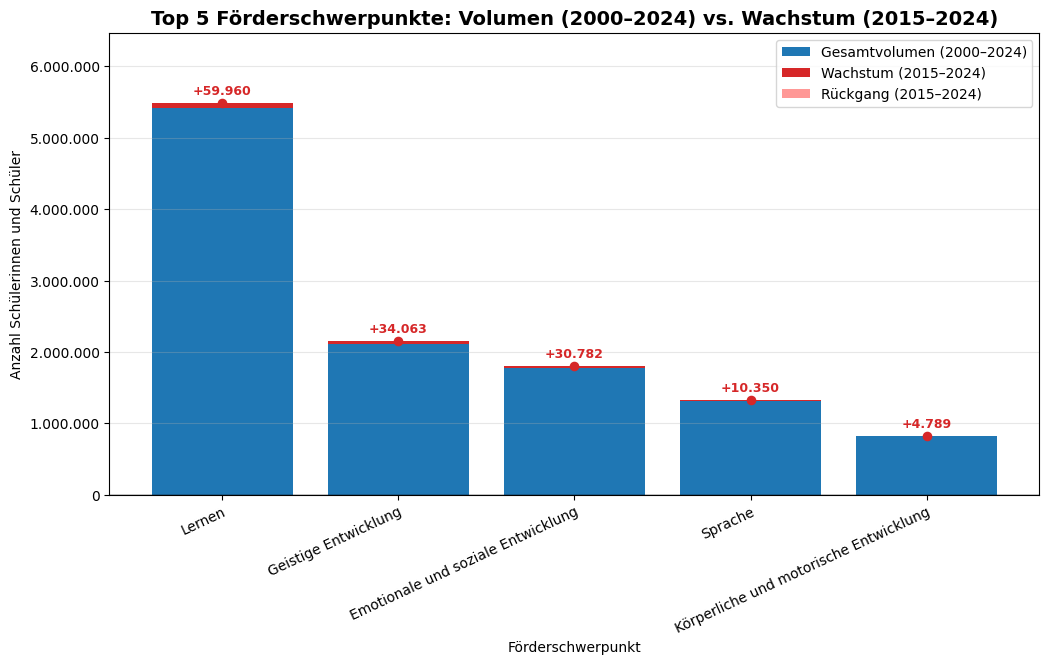

In [20]:
# ============================================================
# 4.2 Visual V05: Top 5 Förderschwerpunkte – Volumen und Wachstum
# ============================================================

# Ziel:
# Gesamtvolumen (2000–2024) und Wachstum (2015–2024) gemeinsam darstellen.
# Anpassung:
# Das Wachstum wird zusätzlich als roter Marker/Label sichtbar gemacht,
# weil der rote Anteil im Verhältnis zum Gesamtvolumen sehr klein ist.
# Hinweis:
# Wachstum wird als zusätzliche Dynamik visualisiert, nicht als Bestandteil des Gesamtvolumens interpretiert.

# ------------------------------------------------------------
# Daten vorbereiten
# ------------------------------------------------------------

df_plot_dist = (
    df_schwerpunkt_summe
    .sort_values("anzahl_schueler", ascending=False)
    .head(5)
)

df_plot_growth = df_treiber_schwerpunkt.copy()

df_plot = df_plot_dist.merge(
    df_plot_growth[["foerderschwerpunkt", "veraenderung_abs"]],
    on="foerderschwerpunkt",
    how="left"
)

df_plot["veraenderung_abs"] = df_plot["veraenderung_abs"].fillna(0)
df_plot["wachstum_pos"] = df_plot["veraenderung_abs"].clip(lower=0)
df_plot["wachstum_neg"] = df_plot["veraenderung_abs"].clip(upper=0)

# ------------------------------------------------------------
# Plot erstellen
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))

x_labels = df_plot["foerderschwerpunkt"].astype(str)
x_pos = range(len(df_plot))

# Gesamtvolumen
ax.bar(
    x_pos,
    df_plot["anzahl_schueler"],
    label="Gesamtvolumen (2000–2024)",
    color="#1f77b4"
)

# Wachstum oben auf dem Gesamtvolumen
ax.bar(
    x_pos,
    df_plot["wachstum_pos"],
    bottom=df_plot["anzahl_schueler"],
    label="Wachstum (2015–2024)",
    color="#d62728"
)

# Rückgang unterhalb der Null-Linie
ax.bar(
    x_pos,
    df_plot["wachstum_neg"],
    label="Rückgang (2015–2024)",
    color="#ff9896"
)

# Roter Markerpunkt auf dem Wachstum, damit der Effekt sichtbar wird
ax.scatter(
    x_pos,
    df_plot["anzahl_schueler"] + df_plot["wachstum_pos"],
    color="#d62728",
    s=35,
    zorder=5
)

# Werte-Label für Wachstum anzeigen
for i, row in df_plot.iterrows():
    wachstum = row["veraenderung_abs"]

    if wachstum > 0:
        ax.text(
            i,
            row["anzahl_schueler"] + row["wachstum_pos"] + 80_000,
            f"+{int(wachstum):,}".replace(",", "."),
            ha="center",
            va="bottom",
            fontsize=9,
            color="#d62728",
            fontweight="bold"
        )
    elif wachstum < 0:
        ax.text(
            i,
            wachstum - 80_000,
            f"{int(wachstum):,}".replace(",", "."),
            ha="center",
            va="top",
            fontsize=9,
            color="#ff9896",
            fontweight="bold"
        )

ax.axhline(0, color="black", linewidth=1)

# Achsenbereich bewusst linear lassen, damit Größenordnung nicht verzerrt wird
y_max = (df_plot["anzahl_schueler"] + df_plot["wachstum_pos"]).max()
y_min = min(0, df_plot["wachstum_neg"].min() * 1.2)
ax.set_ylim(y_min, y_max * 1.18)

# ------------------------------------------------------------
# Formatierung
# ------------------------------------------------------------

ax.set_title(
    "Top 5 Förderschwerpunkte: Volumen (2000–2024) vs. Wachstum (2015–2024)",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Förderschwerpunkt")
ax.set_ylabel("Anzahl Schülerinnen und Schüler")

# X-Achse weniger steil: 25 Grad statt 45 Grad
ax.set_xticks(list(x_pos))
ax.set_xticklabels(x_labels, rotation=25, ha="right", rotation_mode="anchor")

standard_grid(ax)
format_y_axis_thousands(ax)

ax.legend()

# Mehr Platz unten für Labels, aber weniger als vorher nötig
plt.subplots_adjust(bottom=0.22)

save_chart(fig, "05_top5_volumen_wachstum.png")
plt.show()

## Interpretation: Treiberanalyse

Der Anstieg seit 2015 wird nicht gleichmäßig von allen Förderschwerpunkten getragen. Besonders relevant sind die zentralen Kategorien `Lernen`, `Geistige Entwicklung` und `Emotionale und soziale Entwicklung`.

### Einschränkung
Die Darstellung kombiniert Gesamtvolumen und Veränderung. Sie dient der visuellen Einordnung, ersetzt aber keine kausale Analyse.


# 5. Datensatz 2: Gesamtschülerzahlen und Förderanteil

## Ziel
Um die Entwicklung nicht nur absolut, sondern relativ zum Gesamtsystem zu bewerten, wird ein zweiter Datensatz mit der Gesamtzahl der Schülerinnen und Schüler integriert.

## Methodische Entscheidung
Die Datensätze werden auf der gemeinsamen Ebene `jahr + schulart` verbunden. Nur Kombinationen, die in beiden Datensätzen vorkommen, werden für den Förderanteil verwendet.


In [21]:
# ============================================================
# 5.1 CSV einlesen: Gesamtschüler-Datensatz
# ============================================================

# Ziel:
# Zweiten Datensatz einlesen, der als Nenner für Förderanteile genutzt wird.

df_schueler_raw = pd.read_csv(SCHUELER_GESAMT_PATH, sep=";")
df_schueler_clean = df_schueler_raw.copy()

print("Gesamtschüler-Datensatz eingelesen.")
print("Shape Rohdaten:", df_schueler_raw.shape)
df_schueler_raw.head()


Gesamtschüler-Datensatz eingelesen.
Shape Rohdaten: (16875, 26)


,statistics_code,statistics_label,time_code,time_label,time,1_variable_code,1_variable_label,1_variable_attribute_code,1_variable_attribute_label,2_variable_code,2_variable_label,2_variable_attribute_code,2_variable_attribute_label,3_variable_code,3_variable_label,3_variable_attribute_code,3_variable_attribute_label,4_variable_code,4_variable_label,4_variable_attribute_code,4_variable_attribute_label,value,value_unit,value_variable_code,value_variable_label,value_q
0,21111,Statistik der allgemeinbildenden Schulen,SLJAHR,Schuljahr,2005-P1Y,DINSG,Deutschland insgesamt,DG,Deutschland,GES,Geschlecht,GESM,männlich,BILSA1,Schulart,SCHULE10,Freie Waldorfschulen,BILJG1,Jahrgangsstufen,STUFE02,Klassenstufe 2,3136,Anzahl,BIL001,Schüler,e
1,21111,Statistik der allgemeinbildenden Schulen,SLJAHR,Schuljahr,2000-P1Y,DINSG,Deutschland insgesamt,DG,Deutschland,GES,Geschlecht,GESM,männlich,BILSA1,Schulart,SCHULE11,Förderschulen,BILJG1,Jahrgangsstufen,STUFE13,Jahrgangsstufe 13 / Qualifizierungsphase Q2,56,Anzahl,BIL001,Schüler,e
2,21111,Statistik der allgemeinbildenden Schulen,SLJAHR,Schuljahr,2023-P1Y,DINSG,Deutschland insgesamt,DG,Deutschland,GES,Geschlecht,NaN,Insgesamt,BILSA1,Schulart,SCHULE14,Abendgymnasien,BILJG1,Jahrgangsstufen,STUFE07,Klassenstufe 7,-,Anzahl,BIL001,Schüler,NaN
3,21111,Statistik der allgemeinbildenden Schulen,SLJAHR,Schuljahr,2018-P1Y,DINSG,Deutschland insgesamt,DG,Deutschland,GES,Geschlecht,GESW,weiblich,BILSA1,Schulart,SCHULE14,Abendgymnasien,BILJG1,Jahrgangsstufen,STUFE10,Klassenstufe 10,-,Anzahl,BIL001,Schüler,NaN
4,21111,Statistik der allgemeinbildenden Schulen,SLJAHR,Schuljahr,2002-P1Y,DINSG,Deutschland insgesamt,DG,Deutschland,GES,Geschlecht,GESM,männlich,BILSA1,Schulart,SCHULE11,Förderschulen,BILJG1,Jahrgangsstufen,STUFE02,Klassenstufe 2,16866,Anzahl,BIL001,Schüler,e


In [22]:
# ============================================================
# 5.2 Gesamtschüler-Datensatz auf Analyseebene filtern
# ============================================================

# Ziel:
# Nur die Ebene verwenden, die für einen Vergleich nach Jahr + Schulart benötigt wird.
# Im Gesamtschüler-Datensatz werden Geschlecht und Jahrgangsstufe auf "Insgesamt" gefiltert.

df_schueler_clean = df_schueler_clean[
    df_schueler_clean["4_variable_attribute_label"] == "Insgesamt"
].copy()

df_schueler_clean = df_schueler_clean[
    df_schueler_clean["2_variable_attribute_label"] == "Insgesamt"
].copy()

print("Shape nach Aggregationsfilter:", df_schueler_clean.shape)
df_schueler_clean.head()


Shape nach Aggregationsfilter: (375, 26)


,statistics_code,statistics_label,time_code,time_label,time,1_variable_code,1_variable_label,1_variable_attribute_code,1_variable_attribute_label,2_variable_code,2_variable_label,2_variable_attribute_code,2_variable_attribute_label,3_variable_code,3_variable_label,3_variable_attribute_code,3_variable_attribute_label,4_variable_code,4_variable_label,4_variable_attribute_code,4_variable_attribute_label,value,value_unit,value_variable_code,value_variable_label,value_q
68,21111,Statistik der allgemeinbildenden Schulen,SLJAHR,Schuljahr,2016-P1Y,DINSG,Deutschland insgesamt,DG,Deutschland,GES,Geschlecht,NaN,Insgesamt,BILSA1,Schulart,SCHULE06,Schularten mit zwei Bildungsgängen,BILJG1,Jahrgangsstufen,NaN,Insgesamt,520145,Anzahl,BIL001,Schüler,e
71,21111,Statistik der allgemeinbildenden Schulen,SLJAHR,Schuljahr,2000-P1Y,DINSG,Deutschland insgesamt,DG,Deutschland,GES,Geschlecht,NaN,Insgesamt,BILSA1,Schulart,SCHULE07,Realschulen,BILJG1,Jahrgangsstufen,NaN,Insgesamt,1263382,Anzahl,BIL001,Schüler,e
83,21111,Statistik der allgemeinbildenden Schulen,SLJAHR,Schuljahr,2009-P1Y,DINSG,Deutschland insgesamt,DG,Deutschland,GES,Geschlecht,NaN,Insgesamt,BILSA1,Schulart,SCHULE12,Abendhauptschulen,BILJG1,Jahrgangsstufen,NaN,Insgesamt,1159,Anzahl,BIL001,Schüler,e
132,21111,Statistik der allgemeinbildenden Schulen,SLJAHR,Schuljahr,2016-P1Y,DINSG,Deutschland insgesamt,DG,Deutschland,GES,Geschlecht,NaN,Insgesamt,BILSA1,Schulart,SCHULE12,Abendhauptschulen,BILJG1,Jahrgangsstufen,NaN,Insgesamt,809,Anzahl,BIL001,Schüler,e
157,21111,Statistik der allgemeinbildenden Schulen,SLJAHR,Schuljahr,2023-P1Y,DINSG,Deutschland insgesamt,DG,Deutschland,GES,Geschlecht,NaN,Insgesamt,BILSA1,Schulart,SCHULE06,Schularten mit zwei Bildungsgängen,BILJG1,Jahrgangsstufen,NaN,Insgesamt,550067,Anzahl,BIL001,Schüler,e


## 5.3 Entscheidung: Schularten harmonisieren

Der Gesamtschüler-Datensatz weist einzelne Abendschularten getrennt aus:
- Abendhauptschulen,
- Abendrealschulen,
- Abendgymnasien,
- Kollegs.

Im Förderdaten-Kerndatensatz werden diese als `Abendschulen und Kollegs` zusammengefasst. Deshalb wird im Gesamtschüler-Datensatz dieselbe Sammelkategorie gebildet.


In [23]:
# ============================================================
# 5.4 Schularten harmonisieren
# ============================================================

# Ziel:
# Schularten beider Datensätze fachlich vergleichbar machen.

mapping_schulart = {
    "Abendhauptschulen": "Abendschulen und Kollegs",
    "Abendrealschulen": "Abendschulen und Kollegs",
    "Abendgymnasien": "Abendschulen und Kollegs",
    "Kollegs": "Abendschulen und Kollegs"
}

df_schueler_clean["schulart_clean"] = (
    df_schueler_clean["3_variable_attribute_label"]
    .replace(mapping_schulart)
)

df_schueler_clean["schulart_clean"].value_counts().head(15)


schulart_clean
Abendschulen und Kollegs                   100
Schularten mit zwei Bildungsgängen          25
Realschulen                                 25
Förderschulen                               25
Gymnasien (G9)                              25
Gymnasien (G8)                              25
Schulartunabhängige Orientierungsstufen     25
Hauptschulen                                25
Freie Waldorfschulen                        25
Insgesamt                                   25
Grundschulen                                25
Schularten mit drei Bildungsgängen          25
Name: count, dtype: int64

In [24]:
# ============================================================
# 5.5 Gesamtschüler-Datensatz bereinigen und aggregieren
# ============================================================

# Ziel:
# Jahr, Schulart und Gesamtschülerzahl als Analysevariablen erzeugen.

df_schueler_analysis = df_schueler_clean[[
    "time",
    "schulart_clean",
    "value"
]].copy()

df_schueler_analysis = df_schueler_analysis.rename(columns={
    "time": "jahr_raw",
    "schulart_clean": "schulart",
    "value": "anzahl_schueler_gesamt"
})

# Jahr ableiten
df_schueler_analysis["jahr"] = (
    df_schueler_analysis["jahr_raw"]
    .astype(str)
    .str[:4]
    .astype(int)
)

# Gesamtzahl numerisch bereinigen
df_schueler_analysis["anzahl_schueler_gesamt"] = (
    df_schueler_analysis["anzahl_schueler_gesamt"]
    .astype(str)
    .str.strip()
    .replace("-", np.nan)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
)

df_schueler_analysis["anzahl_schueler_gesamt"] = pd.to_numeric(
    df_schueler_analysis["anzahl_schueler_gesamt"],
    errors="coerce"
)

# Fehlende Werte entfernen
df_schueler_analysis = df_schueler_analysis.dropna(
    subset=["anzahl_schueler_gesamt"]
).copy()

# Nicht benötigte Rohspalte entfernen
df_schueler_analysis = df_schueler_analysis.drop(columns=["jahr_raw"])

# Nach Harmonisierung re-aggregieren
df_schueler_analysis = (
    df_schueler_analysis
    .groupby(["jahr", "schulart"], as_index=False, observed=True)["anzahl_schueler_gesamt"]
    .sum()
)

# "Insgesamt" entfernen, weil der spätere Join auf Jahr + Schulart erfolgt
df_schueler_analysis = df_schueler_analysis[
    df_schueler_analysis["schulart"].astype(str) != "Insgesamt"
].copy()

# Datentypen finalisieren
df_schueler_analysis["jahr"] = df_schueler_analysis["jahr"].astype(int)
df_schueler_analysis["schulart"] = df_schueler_analysis["schulart"].astype("category")
df_schueler_analysis["anzahl_schueler_gesamt"] = df_schueler_analysis["anzahl_schueler_gesamt"].astype(int)

print("Analyse-Datensatz Gesamtschüler:", df_schueler_analysis.shape)
df_schueler_analysis.head()


Analyse-Datensatz Gesamtschüler: (267, 3)


,jahr,schulart,anzahl_schueler_gesamt
0,2000,Abendschulen und Kollegs,46332
1,2000,Freie Waldorfschulen,69969
2,2000,Förderschulen,420427
3,2000,Grundschulen,3352935
4,2000,Gymnasien (G9),2256861


In [25]:
# ============================================================
# 5.6 Förderdatensatz auf Join-Ebene aggregieren
# ============================================================

# Ziel:
# Förderdaten von Jahr + Schulart + Förderschwerpunkt auf Jahr + Schulart verdichten.

df_foerder_analysis = (
    df_analysis
    .groupby(["jahr", "schulart"], as_index=False, observed=True)["anzahl_schueler"]
    .sum()
    .rename(columns={"anzahl_schueler": "anzahl_schueler_foerder"})
)

df_foerder_analysis["jahr"] = df_foerder_analysis["jahr"].astype(int)
df_foerder_analysis["schulart"] = df_foerder_analysis["schulart"].astype("category")
df_foerder_analysis["anzahl_schueler_foerder"] = df_foerder_analysis["anzahl_schueler_foerder"].astype(float)

print("Förder-Datensatz auf Join-Ebene:", df_foerder_analysis.shape)
df_foerder_analysis.head()


Förder-Datensatz auf Join-Ebene: (242, 3)


,jahr,schulart,anzahl_schueler_foerder
0,2000,Freie Waldorfschulen,14.00
1,2000,Förderschulen,"411,408.00"
2,2000,Grundschulen,"38,533.00"
3,2000,Gymnasien (G9),812.00
4,2000,Hauptschulen,"7,614.00"


In [26]:
# ============================================================
# 5.7 Merge beider Datensätze
# ============================================================

# Ziel:
# Förder-Daten und Gesamtschüler-Daten über Jahr + Schulart verbinden.
# how="inner": Nur Kombinationen übernehmen, für die Zähler und Nenner vorhanden sind.

df_merge = df_foerder_analysis.merge(
    df_schueler_analysis,
    on=["jahr", "schulart"],
    how="inner"
)

# Förderanteil berechnen
df_merge["foerderanteil_prozent"] = (
    df_merge["anzahl_schueler_foerder"] /
    df_merge["anzahl_schueler_gesamt"] * 100
).round(2)

print("Merge-Ergebnis:", df_merge.shape)
print("Fehlende Werte nach Merge:")
print(df_merge.isna().sum())

df_merge.head()


Merge-Ergebnis: (242, 5)
Fehlende Werte nach Merge:
jahr                       0
schulart                   0
anzahl_schueler_foerder    0
anzahl_schueler_gesamt     0
foerderanteil_prozent      0
dtype: int64


,jahr,schulart,anzahl_schueler_foerder,anzahl_schueler_gesamt,foerderanteil_prozent
0,2000,Freie Waldorfschulen,14.00,69969,0.02
1,2000,Förderschulen,"411,408.00",420427,97.85
2,2000,Grundschulen,"38,533.00",3352935,1.15
3,2000,Gymnasien (G9),812.00,2256861,0.04
4,2000,Hauptschulen,"7,614.00",1103878,0.69


# 6. Fragestellung 4: Steigt der Förderanteil auch relativ zum Gesamtsystem?

## Ziel
Die absolute Zunahme wird mit der Entwicklung des Förderanteils verglichen. Dadurch wird geprüft, ob der Anstieg nur durch eine größere Gesamtschülerzahl erklärbar wäre oder ob der Anteil im Bildungssystem ebenfalls steigt.


In [27]:
# ============================================================
# 6.1 Gesamtanteil der Förderung berechnen
# ============================================================

# Ziel:
# Über alle vergleichbaren Schularten pro Jahr summieren und daraus den Förderanteil berechnen.

df_anteil_gesamt = (
    df_merge
    .groupby("jahr", as_index=False)
    .agg(
        anzahl_schueler_foerder=("anzahl_schueler_foerder", "sum"),
        anzahl_schueler_gesamt=("anzahl_schueler_gesamt", "sum")
    )
)

df_anteil_gesamt["foerderanteil_prozent"] = (
    df_anteil_gesamt["anzahl_schueler_foerder"] /
    df_anteil_gesamt["anzahl_schueler_gesamt"] * 100
).round(2)

df_anteil_gesamt["veraenderung_zum_vorjahr_pp"] = (
    df_anteil_gesamt["foerderanteil_prozent"].diff()
).round(2)

df_anteil_gesamt.head()


,jahr,anzahl_schueler_foerder,anzahl_schueler_gesamt,foerderanteil_prozent,veraenderung_zum_vorjahr_pp
0,2000,"466,921.00",9849745,4.74,NaN
1,2001,"474,998.00",9759291,4.87,0.13
2,2002,"483,105.00",9673315,4.99,0.12
3,2003,"478,409.00",9616345,4.97,-0.02
4,2004,"476,958.00",9516608,5.01,0.04


PNG gespeichert: ..\outputs\charts\06_foerderanteil_dynamik.png


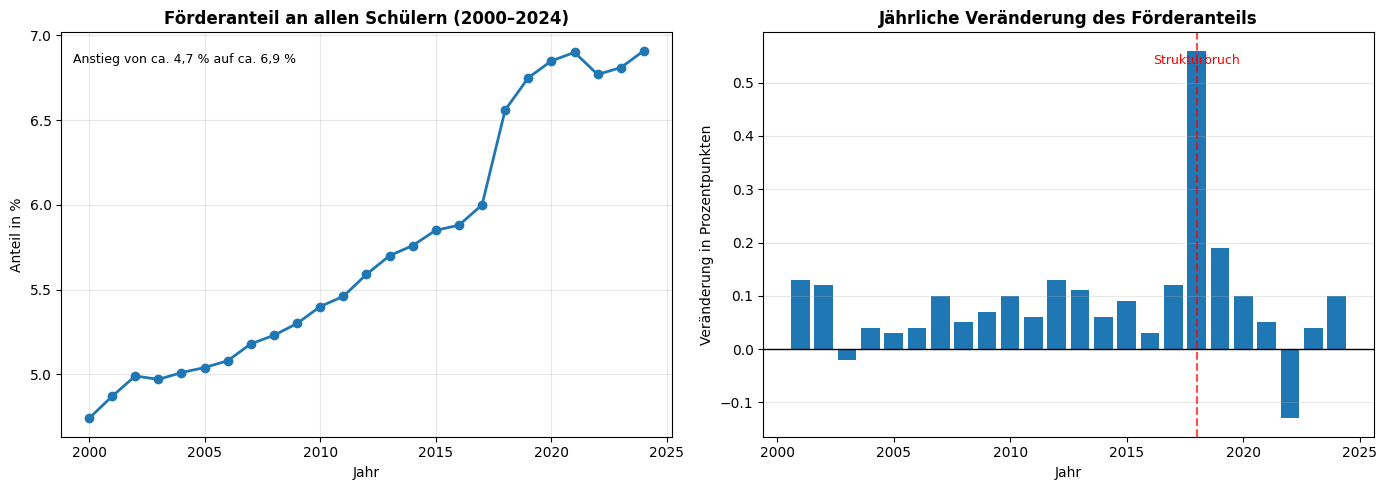

In [28]:
# ============================================================
# 6.2 Visual V06: Förderanteil und jährliche Veränderung
# ============================================================

# Ziel:
# Links: Niveau des Förderanteils über die Zeit.
# Rechts: jährliche Veränderung in Prozentpunkten.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------------------------
# Links: Förderanteil
# ------------------------------------------------------------
ax1.plot(
    df_anteil_gesamt["jahr"],
    df_anteil_gesamt["foerderanteil_prozent"],
    marker="o",
    linewidth=2
)
ax1.set_title("Förderanteil an allen Schülern (2000–2024)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Jahr")
ax1.set_ylabel("Anteil in %")
standard_grid(ax1, axis="both")
ax1.text(
    0.02,
    0.95,
    "Anstieg von ca. 4,7 % auf ca. 6,9 %",
    transform=ax1.transAxes,
    va="top",
    fontsize=9
)

# ------------------------------------------------------------
# Rechts: jährliche Veränderung
# ------------------------------------------------------------
ax2.bar(
    df_anteil_gesamt["jahr"],
    df_anteil_gesamt["veraenderung_zum_vorjahr_pp"]
)
ax2.axhline(0, color="black", linewidth=1)
ax2.axvline(x=2018, color="red", linestyle="--", alpha=0.7)
ax2.set_title("Jährliche Veränderung des Förderanteils", fontsize=12, fontweight="bold")
ax2.set_xlabel("Jahr")
ax2.set_ylabel("Veränderung in Prozentpunkten")
standard_grid(ax2)
ax2.text(2018, ax2.get_ylim()[1] * 0.9, "Strukturbruch", color="red", ha="center", fontsize=9)

plt.tight_layout()
save_chart(fig, "06_foerderanteil_dynamik.png")
plt.show()


PNG gespeichert: ..\outputs\charts\07_absolute_vs_relative_entwicklung.png


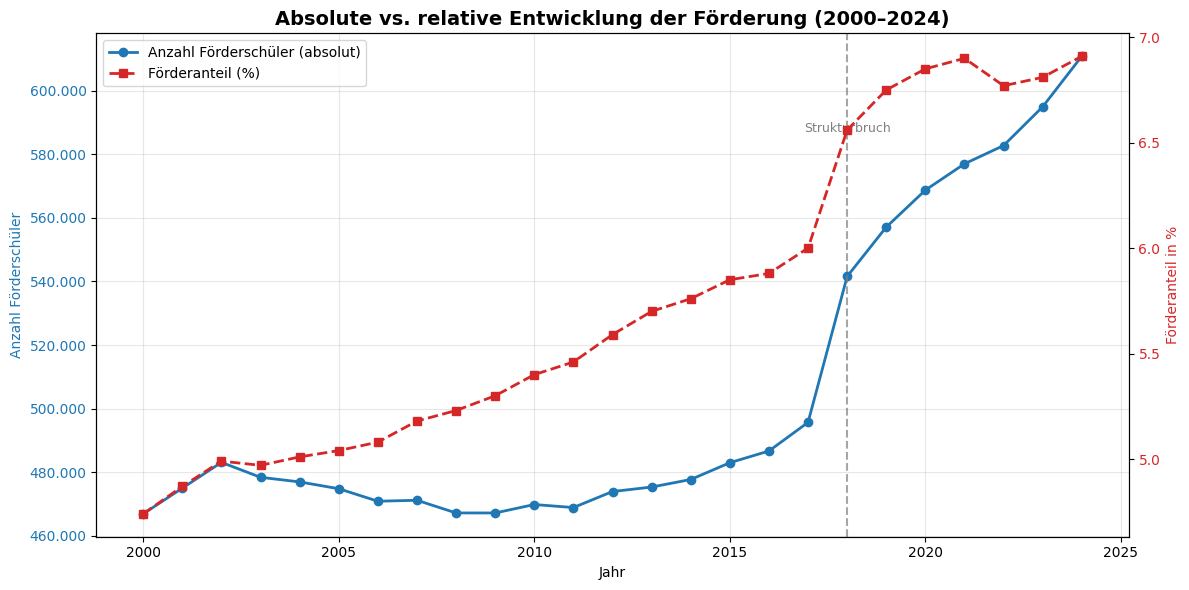

In [29]:
# ============================================================
# 6.3 Visual V07: Absolute vs. relative Entwicklung
# ============================================================

# Ziel:
# Absolute Zahl der Förderung und relativen Förderanteil gemeinsam darstellen.

df_abs_rel = df_anteil_gesamt[[
    "jahr",
    "anzahl_schueler_foerder",
    "anzahl_schueler_gesamt",
    "foerderanteil_prozent"
]].copy()

fig, ax1 = plt.subplots(figsize=(12, 6))

# ------------------------------------------------------------
# Linke Achse: absolute Zahlen
# ------------------------------------------------------------
ax1.plot(
    df_abs_rel["jahr"],
    df_abs_rel["anzahl_schueler_foerder"],
    color="tab:blue",
    marker="o",
    linewidth=2,
    label="Anzahl Förderschüler (absolut)"
)
ax1.set_xlabel("Jahr")
ax1.set_ylabel("Anzahl Förderschüler", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
format_y_axis_thousands(ax1)
standard_grid(ax1, axis="both")

# ------------------------------------------------------------
# Rechte Achse: Förderanteil
# ------------------------------------------------------------
ax2 = ax1.twinx()
ax2.plot(
    df_abs_rel["jahr"],
    df_abs_rel["foerderanteil_prozent"],
    color="tab:red",
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Förderanteil (%)"
)
ax2.set_ylabel("Förderanteil in %", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# Strukturbruch markieren
ax1.axvline(x=2018, color="gray", linestyle="--", alpha=0.7)
ax1.text(2018, ax1.get_ylim()[1] * 0.95, "Strukturbruch", ha="center", fontsize=9, color="gray")

# Gemeinsame Legende
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.title("Absolute vs. relative Entwicklung der Förderung (2000–2024)", fontsize=14, fontweight="bold")
plt.tight_layout()
save_chart(fig, "07_absolute_vs_relative_entwicklung.png")
plt.show()


## Interpretation: Förderanteil

Der Förderanteil steigt von ca. 4,7 % auf ca. 6,9 %. Damit wächst der Förderbedarf nicht nur absolut, sondern auch relativ zur Gesamtzahl der Schülerinnen und Schüler. Der Anstieg kann daher nicht allein durch eine größere Gesamtschülerzahl erklärt werden.

### Kernaussage
Die parallele Zunahme von absoluter Zahl und relativem Anteil spricht für eine strukturelle Entwicklung im Bildungssystem.


# 7. Kontextualisierung: externe Ereignisse und Systemveränderungen

## Ziel
Der Verlauf des Förderanteils wird mit ausgewählten externen Ereignissen zeitlich eingeordnet.

## Methodischer Hinweis
Die Markierungen dienen nur der Kontextualisierung. Sie beweisen keine Ursache-Wirkungs-Beziehung.


PNG gespeichert: ..\outputs\charts\08_foerderanteil_ereignisse.png


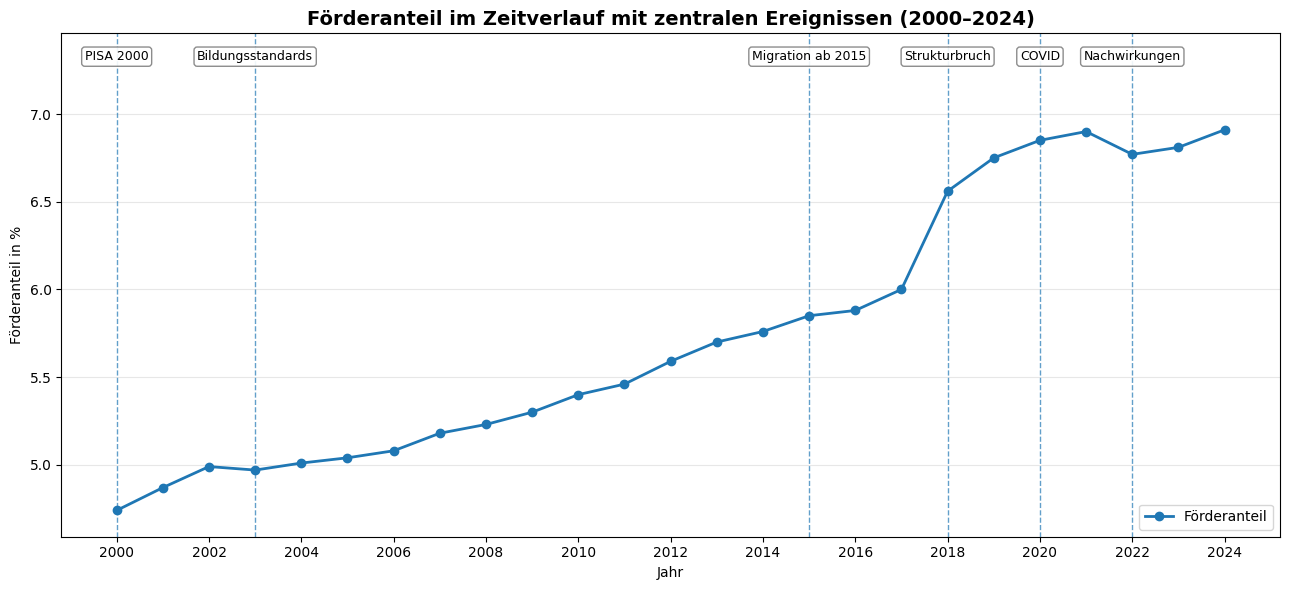

In [30]:
# ============================================================
# 7.1 Visual V08: Förderanteil mit Ereignis-Markierungen
# ============================================================

# Ziel:
# Zeitliche Einordnung zentraler externer Ereignisse und möglicher Systemveränderungen.

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    df_anteil_gesamt["jahr"],
    df_anteil_gesamt["foerderanteil_prozent"],
    marker="o",
    linewidth=2,
    label="Förderanteil"
)

# Ereignisse definieren
ereignisse = {
    2000: "PISA 2000",
    2003: "Bildungsstandards",
    2015: "Migration ab 2015",
    2018: "Strukturbruch",
    2020: "COVID",
    2022: "Nachwirkungen"
}

# Platz für Labels schaffen
y_min = df_anteil_gesamt["foerderanteil_prozent"].min()
y_max = df_anteil_gesamt["foerderanteil_prozent"].max()
ax.set_ylim(y_min - 0.15, y_max + 0.55)
label_y = y_max + 0.38

# Ereignislinien und Labels
for jahr, label in ereignisse.items():
    ax.axvline(x=jahr, linestyle="--", linewidth=1, alpha=0.7)
    ax.text(
        jahr,
        label_y,
        label,
        ha="center",
        va="bottom",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="gray", alpha=0.9)
    )

ax.set_title("Förderanteil im Zeitverlauf mit zentralen Ereignissen (2000–2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Jahr")
ax.set_ylabel("Förderanteil in %")
ax.set_xticks(range(2000, 2025, 2))
standard_grid(ax)
ax.legend(loc="lower right")

plt.tight_layout()
save_chart(fig, "08_foerderanteil_ereignisse.png")
plt.show()


## Interpretation: Kontextualisierung

Die stärkste Veränderung zeigt sich ab 2017/2018. Mehrere externe Ereignisse liegen zeitlich in der Nähe, darunter Migration ab 2015 und COVID-19 ab 2020. Die Daten zeigen jedoch keinen eindeutigen Zusammenhang mit einem einzelnen Ereignis.

### Kernaussage
Der Verlauf spricht eher für eine strukturelle Entwicklung mit mehreren möglichen Einflussfaktoren als für einen einzelnen Auslöser.


# 8. Hypothesenprüfung

## Ziel
Auf Basis der deskriptiven Analyse werden zwei Hypothesen geprüft. Die Hypothesen ergeben sich aus den beobachteten Auffälligkeiten im Zeitverlauf und werden bewusst getrennt betrachtet.

## Hypothesen

**H1:** Die verstärkte Zuwanderung ab 2015 hängt mit einem zeitverzögerten Anstieg des Förderanteils zusammen.

**H2:** COVID-19 führte zu einem starken zusätzlichen Anstieg des Förderanteils.

## Methodischer Hinweis
Beide Hypothesen werden mit den vorhandenen Daten nur explorativ geprüft. Der Datensatz enthält keine direkten Variablen zu Migration oder COVID-19. Deshalb sind nur zeitliche Zusammenhänge bewertbar, keine Kausalität.


PNG gespeichert: ..\outputs\charts\09_hypothese_migration.png


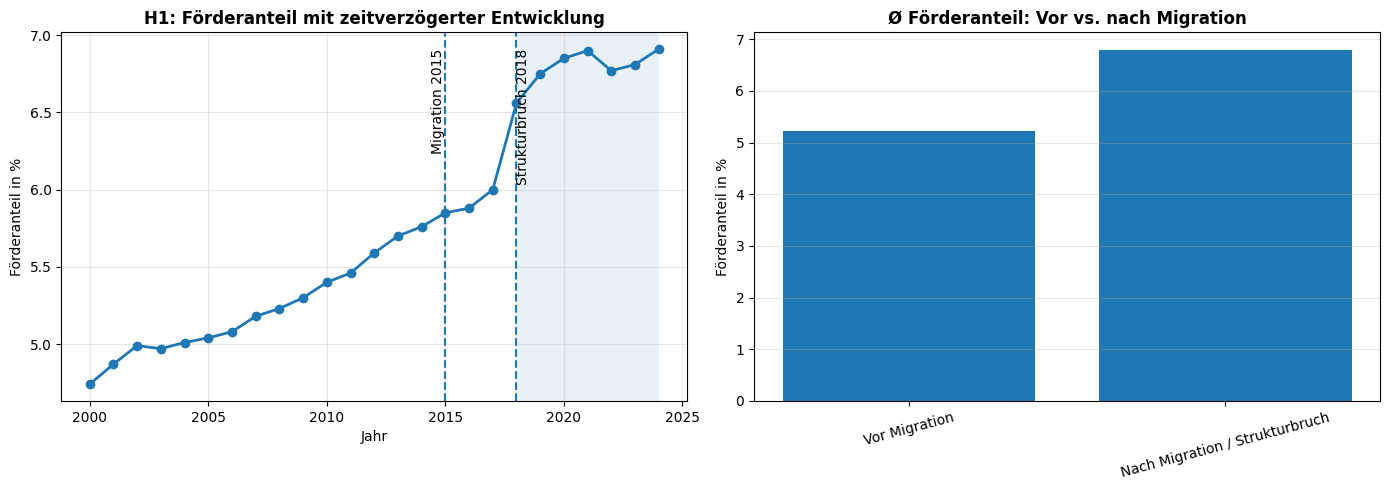

,Phase,foerderanteil_mittelwert
0,Vor Migration,5.22
1,Nach Migration / Strukturbruch,6.79


In [31]:
# ============================================================
# 8.1 Hypothese H1: Migration - Zeitverlauf und Mittelwertvergleich
# ============================================================

# Ziel:
# Prüfen, ob nach 2015 ein zeitverzögerter Anstieg im Förderanteil sichtbar ist.

# ------------------------------------------------------------
# Mittelwerte berechnen
# ------------------------------------------------------------
vor_migration = df_anteil_gesamt[
    df_anteil_gesamt["jahr"] <= 2014
]["foerderanteil_prozent"].mean()

nach_migration = df_anteil_gesamt[
    df_anteil_gesamt["jahr"] >= 2018
]["foerderanteil_prozent"].mean()

df_compare_migration = pd.DataFrame({
    "Phase": ["Vor Migration", "Nach Migration / Strukturbruch"],
    "foerderanteil_mittelwert": [vor_migration, nach_migration]
})

# ------------------------------------------------------------
# Visual erstellen
# ------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Links: Zeitverlauf
ax1.plot(
    df_anteil_gesamt["jahr"],
    df_anteil_gesamt["foerderanteil_prozent"],
    marker="o",
    linewidth=2
)
ax1.axvspan(2018, 2024, alpha=0.1)
ax1.axvline(2015, linestyle="--")
ax1.axvline(2018, linestyle="--")

h1_y_max = df_anteil_gesamt["foerderanteil_prozent"].max()
ax1.text(2015, h1_y_max, "Migration 2015", rotation=90, va="top", ha="right")
ax1.text(2018, h1_y_max, "Strukturbruch 2018", rotation=90, va="top", ha="left")

ax1.set_title("H1: Förderanteil mit zeitverzögerter Entwicklung", fontsize=12, fontweight="bold")
ax1.set_xlabel("Jahr")
ax1.set_ylabel("Förderanteil in %")
standard_grid(ax1, axis="both")

# Rechts: Mittelwertvergleich
ax2.bar(
    df_compare_migration["Phase"],
    df_compare_migration["foerderanteil_mittelwert"]
)
ax2.set_title("Ø Förderanteil: Vor vs. nach Migration", fontsize=12, fontweight="bold")
ax2.set_ylabel("Förderanteil in %")
ax2.tick_params(axis="x", rotation=15)
standard_grid(ax2)

plt.tight_layout()
save_chart(fig, "09_hypothese_migration.png")
plt.show()

df_compare_migration


## Ergebnis H1: Migration ab 2015

Die Hypothese wird teilweise gestützt. Ein unmittelbarer Sprung im Jahr 2015 ist nicht sichtbar. Der Förderanteil steigt jedoch ab den Folgejahren deutlich stärker und liegt nach dem Strukturbruch im Durchschnitt höher als davor.

### Interpretation
Die Daten zeigen einen zeitlichen Zusammenhang mit Verzögerung. Ob Migration tatsächlich ein Einflussfaktor ist, müsste mit zusätzlichen Migrationsdaten geprüft werden.


PNG gespeichert: ..\outputs\charts\10_hypothese_covid.png


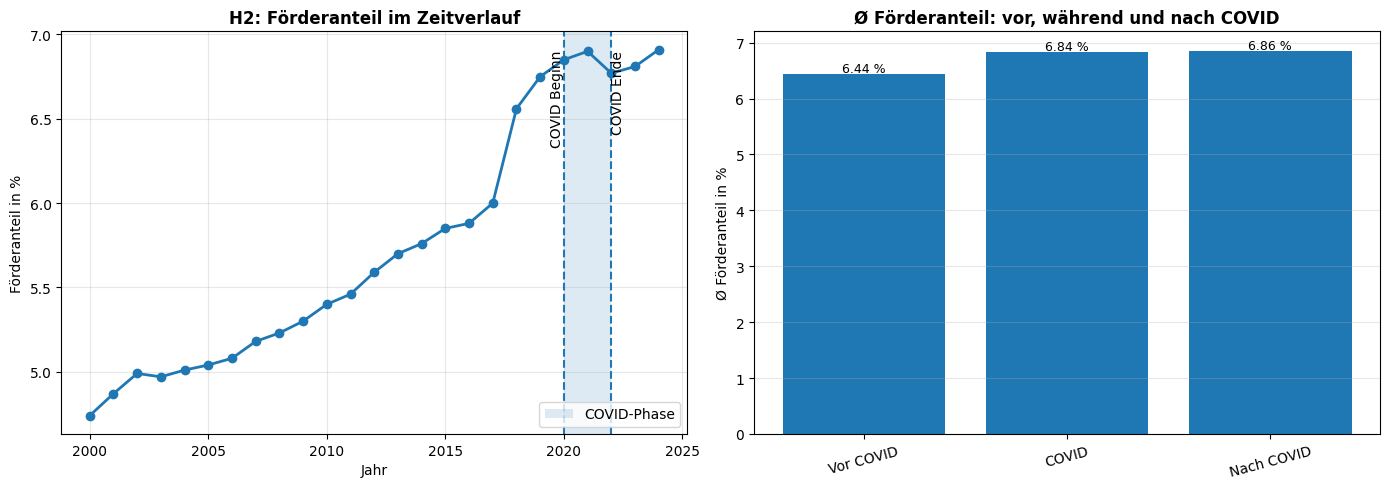

,Phase,foerderanteil_mittelwert
0,Vor COVID,6.44
1,COVID,6.84
2,Nach COVID,6.86


In [32]:
# ============================================================
# 8.2 Hypothese H2: COVID-19 - Zeitverlauf und Mittelwertvergleich
# ============================================================

# Ziel:
# Prüfen, ob während der COVID-Phase 2020–2022 ein zusätzlicher Sprung sichtbar wird.

# ------------------------------------------------------------
# Phasen berechnen
# ------------------------------------------------------------
vor_covid = df_anteil_gesamt[
    (df_anteil_gesamt["jahr"] >= 2017) &
    (df_anteil_gesamt["jahr"] <= 2019)
]["foerderanteil_prozent"].mean()

covid = df_anteil_gesamt[
    (df_anteil_gesamt["jahr"] >= 2020) &
    (df_anteil_gesamt["jahr"] <= 2022)
]["foerderanteil_prozent"].mean()

nach_covid = df_anteil_gesamt[
    df_anteil_gesamt["jahr"] >= 2023
]["foerderanteil_prozent"].mean()

df_covid = pd.DataFrame({
    "Phase": ["Vor COVID", "COVID", "Nach COVID"],
    "foerderanteil_mittelwert": [vor_covid, covid, nach_covid]
})

# ------------------------------------------------------------
# Visual erstellen
# ------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Links: Zeitverlauf mit COVID-Markierung
ax1.plot(
    df_anteil_gesamt["jahr"],
    df_anteil_gesamt["foerderanteil_prozent"],
    marker="o",
    linewidth=2
)
ax1.axvspan(2020, 2022, alpha=0.15, label="COVID-Phase")
ax1.axvline(2020, linestyle="--")
ax1.axvline(2022, linestyle="--")

h2_y_max = df_anteil_gesamt["foerderanteil_prozent"].max()
ax1.text(2020, h2_y_max, "COVID Beginn", rotation=90, va="top", ha="right")
ax1.text(2022, h2_y_max, "COVID Ende", rotation=90, va="top", ha="left")

ax1.set_title("H2: Förderanteil im Zeitverlauf", fontsize=12, fontweight="bold")
ax1.set_xlabel("Jahr")
ax1.set_ylabel("Förderanteil in %")
standard_grid(ax1, axis="both")
ax1.legend(loc="lower right")

# Rechts: Mittelwertvergleich
ax2.bar(
    df_covid["Phase"],
    df_covid["foerderanteil_mittelwert"]
)
ax2.set_title("Ø Förderanteil: vor, während und nach COVID", fontsize=12, fontweight="bold")
ax2.set_ylabel("Ø Förderanteil in %")
ax2.tick_params(axis="x", rotation=15)
standard_grid(ax2)

# Werte über Balken anzeigen
for i, value in enumerate(df_covid["foerderanteil_mittelwert"]):
    ax2.text(i, value + 0.03, f"{value:.2f} %", ha="center", fontsize=9)

plt.tight_layout()
save_chart(fig, "10_hypothese_covid.png")
plt.show()

df_covid


## Ergebnis H2: COVID-19

Die Hypothese wird nicht klar bestätigt. Während und nach COVID liegt der Förderanteil zwar auf einem höheren Niveau als davor, der stärkste Anstieg beginnt jedoch bereits vor der COVID-Phase.

### Interpretation
COVID-19 kann auf Basis dieses Datensatzes eher als möglicher Verstärker eines bestehenden Trends eingeordnet werden, nicht als klar isolierbarer eigenständiger Treiber.


# 9. Zusammenfassung der Fragestellungen und Hypothesen

## Ziel
Am Ende werden alle Fragestellungen und Hypothesen mit Ergebnis und Interpretation zusammengeführt.


## 9.1 Übersicht: Fragestellungen, Antworten und Interpretation

| Nr. | Fragestellung | Ergebnis | Interpretation |
|---|---|---|---|
| F1 | Wie entwickelt sich die Gesamtzahl der Schülerinnen und Schüler mit sonderpädagogischer Förderung? | Langfristiger Anstieg, besonders ab 2017/2018 deutlich stärker. | Die Förderung nimmt im betrachteten Zeitraum sichtbar zu. |
| F2 | In welchen Schularten tritt sonderpädagogische Förderung besonders häufig auf? | Förderschulen dominieren, aber allgemeine Schularten gewinnen an Bedeutung. | Hinweise auf stärkere Sichtbarkeit bzw. Integration im Regelschulsystem. |
| F3 | Welche Förderschwerpunkte dominieren insgesamt? | `Lernen` ist der größte Bereich; danach `Geistige Entwicklung` und `Emotionale und soziale Entwicklung`. | Das Fördervolumen ist stark auf wenige Bereiche konzentriert. |
| F4 | Wie verschieben sich die wichtigsten Förderschwerpunkte im Zeitverlauf? | `Lernen` verliert relativ an Anteil; `Emotionale und soziale Entwicklung` wächst stark. | Das System wird differenzierter, strukturelle Verschiebung innerhalb der Förderung. |
| F5 | Welche Bereiche treiben den Anstieg seit 2015? | Wachstum wird von wenigen zentralen Förderschwerpunkten getragen. | Der Anstieg ist nicht gleichmäßig über alle Kategorien verteilt. |
| F6 | Steigt der Förderbedarf auch relativ zur Gesamtschülerzahl? | Förderanteil steigt von ca. 4,7 % auf ca. 6,9 %. | Der Anstieg ist nicht nur durch mehr Schüler erklärbar, sondern weist auf strukturelles Wachstum hin. |


## 9.2 Übersicht: Hypothesen, Ergebnis und Interpretation

| Hypothese | Erwartung | Ergebnis | Interpretation |
|---|---|---|---|
| H1: Migration ab 2015 hängt mit einem zeitverzögerten Anstieg des Förderanteils zusammen. | Kein unmittelbarer Sprung 2015, aber sichtbare Veränderung in Folgejahren. | Teilweise gestützt: Anstieg zeigt sich zeitverzögert ab 2017/2018. | Zeitlicher Zusammenhang sichtbar, aber keine Kausalität. Zusätzliche Migrationsdaten wären erforderlich. |
| H2: COVID-19 führte zu einem starken zusätzlichen Anstieg des Förderanteils. | Klarer zusätzlicher Sprung im Zeitraum 2020–2022. | Nicht klar bestätigt: Trend setzt sich fort, kein isolierter zusätzlicher Sprung. | COVID eher möglicher Verstärker als eigenständiger Haupttreiber. |


# 10. Gesamtfazit

Die Analyse zeigt eine langfristige Zunahme sonderpädagogischer Förderung in Deutschland. Besonders relevant ist, dass der Förderanteil nicht nur absolut, sondern auch relativ zur Gesamtschülerzahl steigt.

Der zentrale Wendepunkt liegt nicht unmittelbar bei einem einzelnen Ereignis, sondern wird ab etwa 2017/2018 sichtbar. Die stärksten strukturellen Veränderungen zeigen sich in bestimmten Förderschwerpunkten und zunehmend auch außerhalb klassischer Förderschulen.

Die Hypothesenprüfung zeigt:
- Migration ab 2015: teilweise gestützt, aber nur als zeitlicher Zusammenhang.
- COVID-19: kein klar isolierbarer eigenständiger Effekt.

Insgesamt spricht die Analyse für eine strukturelle Transformation des Bildungssystems mit wachsendem Unterstützungsbedarf und stärkerer Sichtbarkeit sonderpädagogischer Förderung.

## Limitationen
- aggregierte Daten, keine Individualdaten,
- keine direkten Variablen zu Migration oder COVID-19,
- keine kausalen Aussagen möglich,
- fehlende Werte können statistische Geheimhaltung darstellen,
- Schularten mussten zwischen Datensätzen harmonisiert werden.
